# Lab 13 (31.3.2026)
1. PCA (4 components) + Logistic Regression on Raisin dataset (70:30 split).
2. SOM clustering on AQI dataset using features: `pm25`, `pm10`, `co`, `o3`.

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

from minisom import MiniSom

In [6]:
raisin = pd.read_csv("Lab 13-31.3.26-20260407/Raisin.csv")

X = raisin.drop("Class", axis=1)
y = raisin["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [7]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

transformers = [("num", StandardScaler(), num_cols)]
if cat_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols))

model = Pipeline([
    ("prep", ColumnTransformer(transformers)),
    ("pca", PCA(n_components=4)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42)),
])

In [8]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Q1 Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Q1 Accuracy: 0.8518518518518519
              precision    recall  f1-score   support

       Besni       0.89      0.81      0.84       135
     Kecimen       0.82      0.90      0.86       135

    accuracy                           0.85       270
   macro avg       0.85      0.85      0.85       270
weighted avg       0.85      0.85      0.85       270



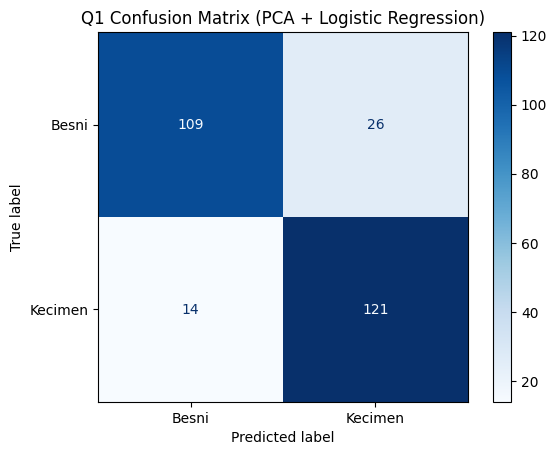

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Q1 Confusion Matrix (PCA + Logistic Regression)")
plt.show()


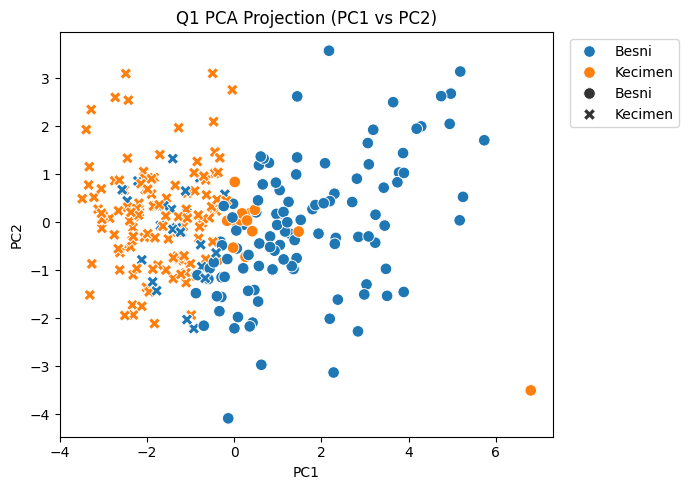

In [10]:
X_test_pca = model.named_steps["pca"].transform(model.named_steps["prep"].transform(X_test))
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_test, style=y_pred, s=70)
plt.title("Q1 PCA Projection (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [11]:
aqi = pd.read_csv("Lab 13-31.3.26-20260407/aqi.csv")

som_features = ["pm25", "pm10", "co", "o3"]
X_som_df = aqi[som_features].apply(pd.to_numeric, errors="coerce")
X_som_df = X_som_df.fillna(X_som_df.median())


In [12]:
scaler_som = MinMaxScaler()
X_som = scaler_som.fit_transform(X_som_df)

som = MiniSom(x=3, y=3, input_len=len(som_features), sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_som)
som.train_random(X_som, 2000)

In [13]:
winners = np.array([som.winner(x) for x in X_som])
aqi["cluster"] = [r * 3 + c for r, c in winners]

print("Q2 Quantization Error:", som.quantization_error(X_som))
print("Q2 Topographic Error:", som.topographic_error(X_som))
print("Q2 Cluster Counts:")
print(aqi["cluster"].value_counts().sort_index())

Q2 Quantization Error: 0.16817393745721188
Q2 Topographic Error: 0.14657742622452083
Q2 Cluster Counts:
cluster
0    2455
1    3888
2    3673
3    4223
4    3220
5    2967
6    2955
7    6292
8    3197
Name: count, dtype: int64


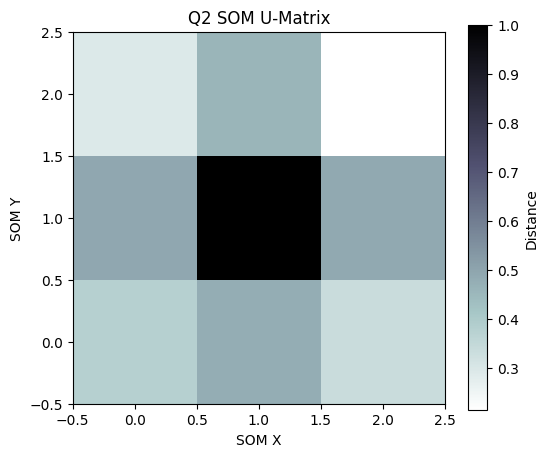

In [14]:
plt.figure(figsize=(6, 5))
plt.imshow(som.distance_map().T, cmap="bone_r", origin="lower")
plt.colorbar(label="Distance")
plt.title("Q2 SOM U-Matrix")
plt.xlabel("SOM X")
plt.ylabel("SOM Y")
plt.show()

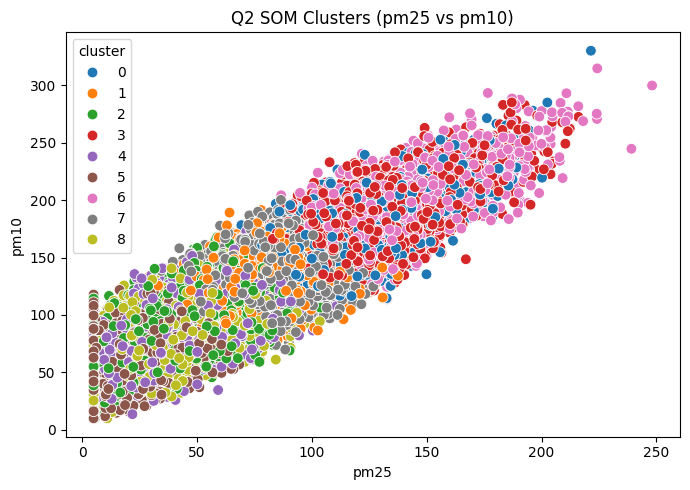

In [15]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=aqi, x="pm25", y="pm10", hue="cluster", palette="tab10", s=60)
plt.title("Q2 SOM Clusters (pm25 vs pm10)")
plt.tight_layout()
plt.show()